# Clasificación de hojas de árboles: ResNet (CNN) vs. ViT

Comparación de desempeño entre una **CNN (ResNet-50)** y un **Vision Transformer (ViT-B/16)**
sobre un dataset de hojas organizado en carpetas `train / valid / test`, donde cada clase
está en su propia subcarpeta.

**Estructura esperada del dataset:**
```
dataset/
├── train/
│   ├── clase_A/  img1.jpg ...
│   ├── clase_B/  ...
├── valid/
│   ├── clase_A/  ...
│   ├── clase_B/  ...
└── test/
    ├── clase_A/  ...
    └── clase_B/  ...
```

**Flujo del notebook:**
1. Configuración y carga de datos (`ImageFolder`)
2. Definición de modelos con *transfer learning* (pesos preentrenados en ImageNet)
3. Bucle de entrenamiento reutilizable (con AMP, scheduler y guardado del mejor modelo)
4. Entrenamiento de ResNet-50 y ViT-B/16
5. Evaluación en `test` (accuracy, F1, reporte por clase, matriz de confusión)
6. Comparación lado a lado de ambos modelos

> Ambos modelos usan la **misma resolución (224×224)** y la **misma normalización de ImageNet**,
> para que la comparación sea justa y compartan los mismos `DataLoader`.

## 0. Dependencias

Si te falta algún paquete, descomenta y ejecuta la siguiente celda.

In [1]:
!pip install torch torchvision scikit-learn matplotlib seaborn pandas tqdm

## 1. Imports y configuración

In [2]:
import os
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)

# tqdm funciona tanto en notebook como en consola
try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

In [3]:
# ----------------------------- CONFIGURACIÓN -----------------------------
# >>> AJUSTA ESTA RUTA a la carpeta raíz de tu dataset <<<
DATA_DIR = Path("Dataset_split_Aug")          # debe contener train/ valid/ test/

IMG_SIZE     = 224                  # 224 lo requieren tanto ResNet como ViT-B/16
BATCH_SIZE   = 32                   # baja a 16 si te quedas sin memoria de GPU
NUM_WORKERS  = 0                    # pon 0 en Windows si da problemas
EPOCHS       = 15
LR           = 3e-4                 # learning rate del head/fine-tuning
WEIGHT_DECAY = 1e-4
FREEZE_BACKBONE = False             # True = entrena solo la cabeza (más rápido, suele rendir algo menos)
LABEL_SMOOTHING = 0.1
SEED = 42

OUTPUT_DIR = Path("checkpoints")
OUTPUT_DIR.mkdir(exist_ok=True)

# Reproducibilidad
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = (DEVICE == "cuda")        # mixed precision solo tiene sentido en GPU
print("Dispositivo:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda
GPU: NVIDIA RTX 6000 Ada Generation


## 2. Transforms y DataLoaders

- **Train:** aumentos de datos (flip, rotación, jitter de color) para mejorar generalización.
- **Valid / Test:** solo *resize* + *center crop* + normalización (sin aleatoriedad).

Ambos modelos comparten estos `DataLoader`.

In [4]:
# Normalización estándar de ImageNet (los pesos preentrenados la esperan)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),   # ~256 si IMG_SIZE=224
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ImageFolder asigna las etiquetas según el nombre de cada subcarpeta (orden alfabético)
train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_tf)
valid_ds = datasets.ImageFolder(DATA_DIR / "valid", transform=eval_tf)
test_ds  = datasets.ImageFolder(DATA_DIR / "test",  transform=eval_tf)

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

pin = (DEVICE == "cuda")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)

print(f"Clases ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Imágenes -> train: {len(train_ds)} | valid: {len(valid_ds)} | test: {len(test_ds)}")

Clases (28): ['Batol_Gourd_Alternaria_Leaf_Blight', 'Batol_Gourd_Anthracnose', 'Batol_Gourd_Downy_Mildew', 'Batol_Gourd_Early_Alternaria_Leaf_Blight', 'Batol_Gourd_Fungal_Damage_Leaf', 'Batol_Gourd_Healthy', 'Batol_Gourd_Mosaic_Virus', 'Tomato_Downy Mildew', 'Tomato_Healthy', 'Tomato_Mosaic', 'Tomato_Spot', 'Tomato_white_spot', 'Zucchini_Angular_Leaf_Spot', 'Zucchini_Anthracnose', 'Zucchini_Downy_Midew', 'Zucchini_Dry_Leaf', 'Zucchini_Healthy', 'Zucchini_Insect_Damage', 'Zucchini_Iron_Chlorosis_Damage', 'Zucchini_Xanthomonas_Leaf_Spot', 'Zucchini_Yellow_Mosaic_Virus', 'papaya_Bacterial_Blight', 'papaya_Carica_Insect_Hole', 'papaya_Curled_Yellow_Spot', 'papaya_Mosaic_Virus', 'papaya_Yellow_Necrotic_Spots_Holes', 'papaya_healthy_leaf', 'papaya_pathogen_symptoms']
Imágenes -> train: 26536 | valid: 772 | test: 813


### 2.1 Distribución de clases y muestra visual

,n_train
Batol_Gourd_Alternaria_Leaf_Blight,909
Batol_Gourd_Anthracnose,917
Batol_Gourd_Downy_Mildew,914
Batol_Gourd_Early_Alternaria_Leaf_Blight,946
Batol_Gourd_Fungal_Damage_Leaf,988
Batol_Gourd_Healthy,922
Batol_Gourd_Mosaic_Virus,905
Tomato_Downy Mildew,982
Tomato_Healthy,1054
Tomato_Mosaic,941


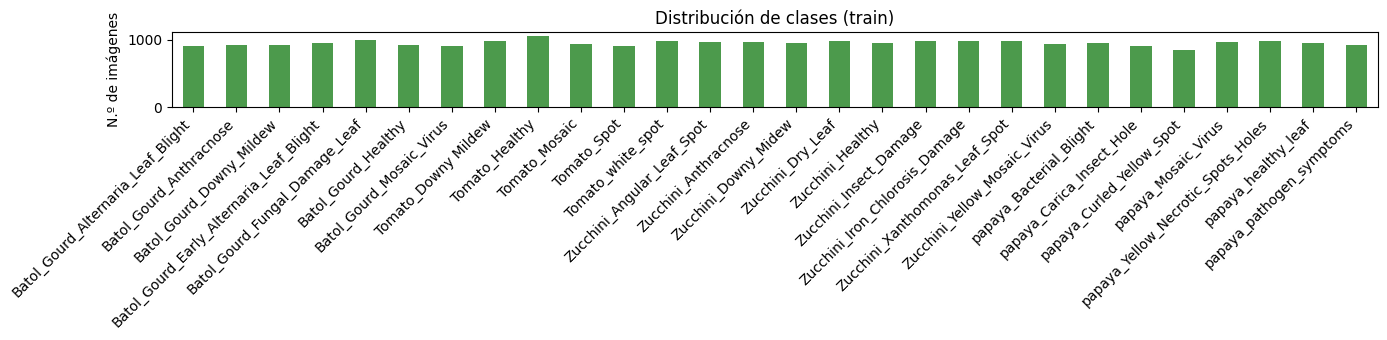

In [5]:
# Conteo de imágenes por clase en el set de entrenamiento
counts = pd.Series([CLASS_NAMES[y] for _, y in train_ds.samples]).value_counts().sort_index()
display(counts.to_frame("n_train"))

plt.figure(figsize=(max(6, NUM_CLASSES * 0.5), 3.5))
counts.plot(kind="bar", color="#4c9a4c")
plt.title("Distribución de clases (train)"); plt.ylabel("N.º de imágenes")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

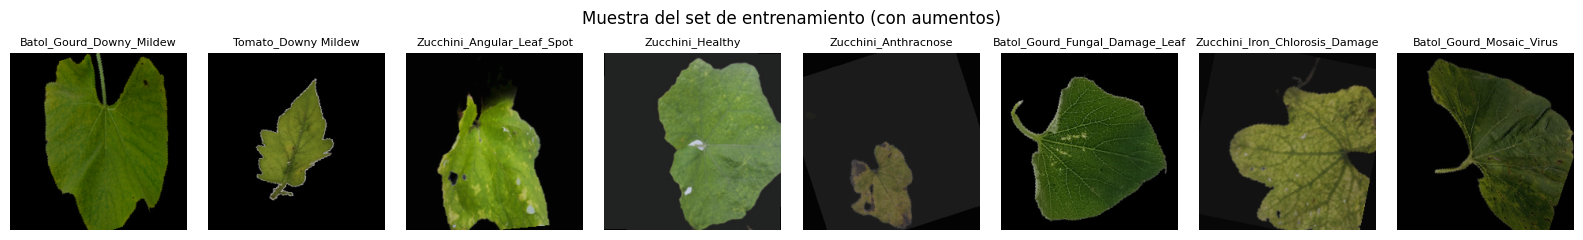

In [6]:
# Visualiza un batch para verificar que los datos cargan bien
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))
n = min(8, len(imgs))
fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.4))
for i in range(n):
    axes[i].imshow(denormalize(imgs[i]).permute(1, 2, 0).numpy())
    axes[i].set_title(CLASS_NAMES[labels[i]], fontsize=8)
    axes[i].axis("off")
plt.suptitle("Muestra del set de entrenamiento (con aumentos)")
plt.tight_layout(); plt.show()

## 3. Definición de los modelos

Usamos *transfer learning*: cargamos pesos preentrenados en ImageNet y reemplazamos la
capa de clasificación final por una nueva de `NUM_CLASSES` salidas.

- **ResNet-50** → capa final `model.fc`
- **ViT-B/16** → capa final `model.heads.head`

Si `FREEZE_BACKBONE = True`, congelamos el *backbone* y entrenamos solo la cabeza nueva.

In [7]:
def build_resnet(num_classes, freeze_backbone=False):
    weights = models.ResNet50_Weights.IMAGENET1K_V2
    model = models.resnet50(weights=weights)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)   # cabeza nueva (siempre entrenable)
    return model

def build_vit(num_classes, freeze_backbone=False):
    weights = models.ViT_B_16_Weights.IMAGENET1K_V1
    model = models.vit_b_16(weights=weights)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 4. Utilidades de entrenamiento y evaluación

Una única función `train_model` sirve para ambos modelos, de modo que se entrenan bajo
condiciones idénticas. Incluye:
- **AMP** (mixed precision) en GPU para acelerar,
- **scheduler** cosine annealing,
- guardado automático del **mejor modelo** según F1-macro de validación,
- registro del **historial** (loss/accuracy/F1 por época).

In [8]:
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """Devuelve loss, accuracy, f1_macro y las predicciones/etiquetas completas."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        logits = model(x)
        if criterion is not None:
            total_loss += criterion(logits, y).item() * x.size(0)
        preds = logits.argmax(1)
        all_preds.append(preds.cpu()); all_labels.append(y.cpu())
        n += x.size(0)
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    loss = total_loss / n if criterion is not None else None
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return loss, acc, f1m, y_true, y_pred

In [9]:
def train_model(model, name, epochs=EPOCHS, lr=LR):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "val_f1"]}
    best_f1, best_state = -1.0, None
    ckpt_path = OUTPUT_DIR / f"best_{name}.pt"

    print(f"\n===== Entrenando {name} | params entrenables: {count_trainable(model):,} =====")
    for epoch in range(1, epochs + 1):
        # ---------------- Train ----------------
        model.train()
        run_loss, run_correct, seen = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{name}] Época {epoch}/{epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            run_loss += loss.item() * x.size(0)
            run_correct += (logits.argmax(1) == y).sum().item()
            seen += x.size(0)
            pbar.set_postfix(loss=f"{run_loss/seen:.3f}", acc=f"{run_correct/seen:.3f}")

        scheduler.step()
        train_loss = run_loss / seen
        train_acc = run_correct / seen

        # ---------------- Validación ----------------
        val_loss, val_acc, val_f1, _, _ = evaluate(model, valid_loader, criterion)
        for k, v in zip(history, [train_loss, train_acc, val_loss, val_acc, val_f1]):
            history[k].append(v)
        print(f"Época {epoch:2d} | train_loss {train_loss:.3f} acc {train_acc:.3f} "
              f"| val_loss {val_loss:.3f} acc {val_acc:.3f} f1 {val_f1:.3f}")

        # Guardar mejor modelo según F1-macro de validación
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_path)

    print(f"Mejor F1-macro de validación ({name}): {best_f1:.4f}  ->  {ckpt_path}")
    model.load_state_dict(best_state)   # restaura los mejores pesos
    return model, history

## 5. Entrenamiento de ResNet-50

In [10]:
set_seed(SEED)
resnet = build_resnet(NUM_CLASSES, freeze_backbone=FREEZE_BACKBONE)
t0 = time.time()
resnet, hist_resnet = train_model(resnet, "resnet50")
time_resnet = time.time() - t0
print(f"Tiempo de entrenamiento ResNet-50: {time_resnet/60:.1f} min")


===== Entrenando resnet50 | params entrenables: 23,565,404 =====


C:\Users\I21325\AppData\Local\Temp\ipykernel_20180\102978612.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


[resnet50] Época 1/15:   0%|          | 0/830 [00:00<?, ?it/s]

C:\Users\I21325\AppData\Local\Temp\ipykernel_20180\102978612.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Época  1 | train_loss 1.545 acc 0.612 | val_loss 1.259 acc 0.727 f1 0.651


...

C:\Users\I21325\AppData\Local\Temp\ipykernel_20180\102978612.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Época 14 | train_loss 0.852 acc 0.882 | val_loss 0.895 acc 0.869 f1 0.799


[resnet50] Época 15/15:   0%|          | 0/830 [00:00<?, ?it/s]

C:\Users\I21325\AppData\Local\Temp\ipykernel_20180\102978612.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Época 15 | train_loss 0.848 acc 0.884 | val_loss 0.891 acc 0.868 f1 0.800
Mejor F1-macro de validación (resnet50): 0.8132  ->  checkpoints\best_resnet50.pt
Tiempo de entrenamiento ResNet-50: 87.4 min


## 6. Entrenamiento de ViT-B/16

In [11]:
set_seed(SEED)
vit = build_vit(NUM_CLASSES, freeze_backbone=FREEZE_BACKBONE)
t0 = time.time()
vit, hist_vit = train_model(vit, "vit_b16")
time_vit = time.time() - t0
print(f"Tiempo de entrenamiento ViT-B/16: {time_vit/60:.1f} min")


===== Entrenando vit_b16 | params entrenables: 85,820,188 =====


C:\Users\I21325\AppData\Local\Temp\ipykernel_20180\102978612.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


[vit_b16] Época 1/15:   0%|          | 0/830 [00:00<?, ?it/s]

C:\Users\I21325\AppData\Local\Temp\ipykernel_20180\102978612.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Época  1 | train_loss 2.318 acc 0.333 | val_loss 2.073 acc 0.417 f1 0.337


...

C:\Users\I21325\AppData\Local\Temp\ipykernel_20180\102978612.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Época 14 | train_loss 0.907 acc 0.858 | val_loss 1.048 acc 0.817 f1 0.754


[vit_b16] Época 15/15:   0%|          | 0/830 [00:00<?, ?it/s]

C:\Users\I21325\AppData\Local\Temp\ipykernel_20180\102978612.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Época 15 | train_loss 0.896 acc 0.861 | val_loss 1.044 acc 0.816 f1 0.755
Mejor F1-macro de validación (vit_b16): 0.7640  ->  checkpoints\best_vit_b16.pt
Tiempo de entrenamiento ViT-B/16: 88.4 min


## 7. Evaluación en el conjunto de test

Cargamos los **mejores pesos** de cada modelo (ya restaurados por `train_model`) y evaluamos
sobre `test`, calculando: accuracy, precision/recall/F1 (macro y ponderado), reporte por clase
y matriz de confusión.

In [18]:
def full_test_report(model, name):
    _, acc, f1m, y_true, y_pred = evaluate(model, test_loader)
    prec_m = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec_m  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_w   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n########## {name} — resultados en TEST ##########")
    print(f"Accuracy         : {acc:.4f}")
    print(f"Precision (macro): {prec_m:.4f}")
    print(f"Recall    (macro): {rec_m:.4f}")
    print(f"F1        (macro): {f1m:.4f}")
    print(f"F1     (weighted): {f1_w:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    metrics = {"model": name, "accuracy": acc, "precision_macro": prec_m,
               "recall_macro": rec_m, "f1_macro": f1m, "f1_weighted": f1_w}
    return metrics, y_true, y_pred

metrics_resnet, yt_r, yp_r = full_test_report(resnet, "ResNet-50")
metrics_vit,    yt_v, yp_v = full_test_report(vit,    "ViT-B/16")


########## ResNet-50 — resultados en TEST ##########
Accuracy         : 0.8844
Precision (macro): 0.8284
Recall    (macro): 0.8283
F1        (macro): 0.8176
F1     (weighted): 0.8814

                                          precision    recall  f1-score   support

      Batol_Gourd_Alternaria_Leaf_Blight       0.96      0.96      0.96        46
                 Batol_Gourd_Anthracnose       0.95      0.98      0.96        42
                Batol_Gourd_Downy_Mildew       0.98      0.91      0.94        44
Batol_Gourd_Early_Alternaria_Leaf_Blight       0.90      1.00      0.95        28
          Batol_Gourd_Fungal_Damage_Leaf       1.00      1.00      1.00         7
                     Batol_Gourd_Healthy       1.00      0.95      0.97        39
                Batol_Gourd_Mosaic_Virus       0.98      1.00      0.99        48
                     Tomato_Downy Mildew       0.91      1.00      0.95        10
                          Tomato_Healthy       1.00      0.98      0.99     

## 8. Comparación de desempeño

### 8.1 Tabla resumen de métricas (test)

In [19]:
summary = pd.DataFrame([metrics_resnet, metrics_vit]).set_index("model")
summary["train_time_min"] = [time_resnet / 60, time_vit / 60]
summary["trainable_params_M"] = [count_trainable(resnet) / 1e6,
                                 count_trainable(vit) / 1e6]
display(summary.round(4))

# Guardar resultados a CSV
summary.round(4).to_csv(OUTPUT_DIR / "comparacion_metricas.csv")
print("Métricas guardadas en", OUTPUT_DIR / "comparacion_metricas.csv")

,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,train_time_min,trainable_params_M
model,,,,,,,
ResNet-50,0.8844,0.8284,0.8283,0.8176,0.8814,87.4499,23.5654
ViT-B/16,0.8253,0.7713,0.7853,0.7683,0.8226,88.3833,85.8202


Métricas guardadas en checkpoints\comparacion_metricas.csv


### 8.2 Curvas de entrenamiento (loss / accuracy / F1 de validación)

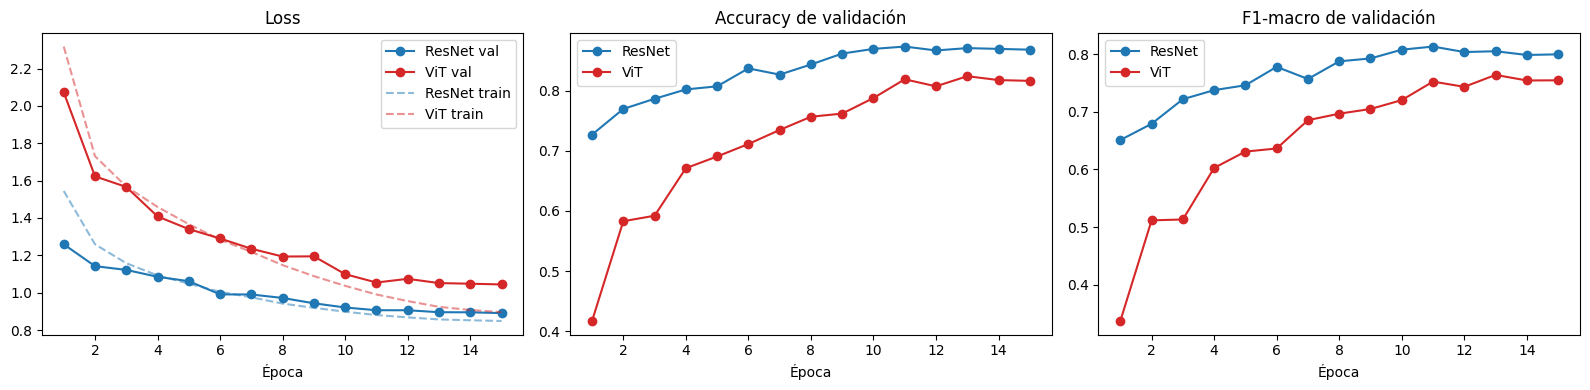

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_range = range(1, len(hist_resnet["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_range, hist_resnet["val_loss"], "-o", label="ResNet val", color="#1f77b4")
axes[0].plot(epochs_range, hist_vit["val_loss"],    "-o", label="ViT val",    color="#d62728")
axes[0].plot(epochs_range, hist_resnet["train_loss"], "--", label="ResNet train", color="#1f77b4", alpha=0.5)
axes[0].plot(epochs_range, hist_vit["train_loss"],    "--", label="ViT train",    color="#d62728", alpha=0.5)
axes[0].set_title("Loss"); axes[0].set_xlabel("Época"); axes[0].legend()

# Accuracy de validación
axes[1].plot(epochs_range, hist_resnet["val_acc"], "-o", label="ResNet", color="#1f77b4")
axes[1].plot(epochs_range, hist_vit["val_acc"],    "-o", label="ViT",    color="#d62728")
axes[1].set_title("Accuracy de validación"); axes[1].set_xlabel("Época"); axes[1].legend()

# F1 de validación
axes[2].plot(epochs_range, hist_resnet["val_f1"], "-o", label="ResNet", color="#1f77b4")
axes[2].plot(epochs_range, hist_vit["val_f1"],    "-o", label="ViT",    color="#d62728")
axes[2].set_title("F1-macro de validación"); axes[2].set_xlabel("Época"); axes[2].legend()

plt.tight_layout(); plt.show()

### 8.3 Comparación visual de métricas en test

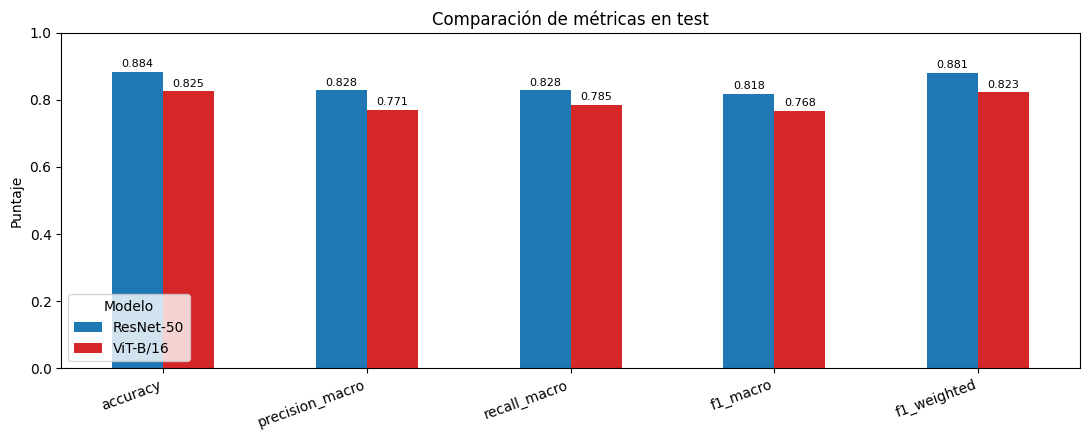

In [15]:
metric_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]
ax = summary[metric_cols].T.plot(kind="bar", figsize=(11, 4.5),
                                 color=["#1f77b4", "#d62728"])
ax.set_title("Comparación de métricas en test")
ax.set_ylabel("Puntaje"); ax.set_ylim(0, 1)
ax.legend(title="Modelo"); plt.xticks(rotation=20, ha="right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout(); plt.show()

### 8.4 Matrices de confusión

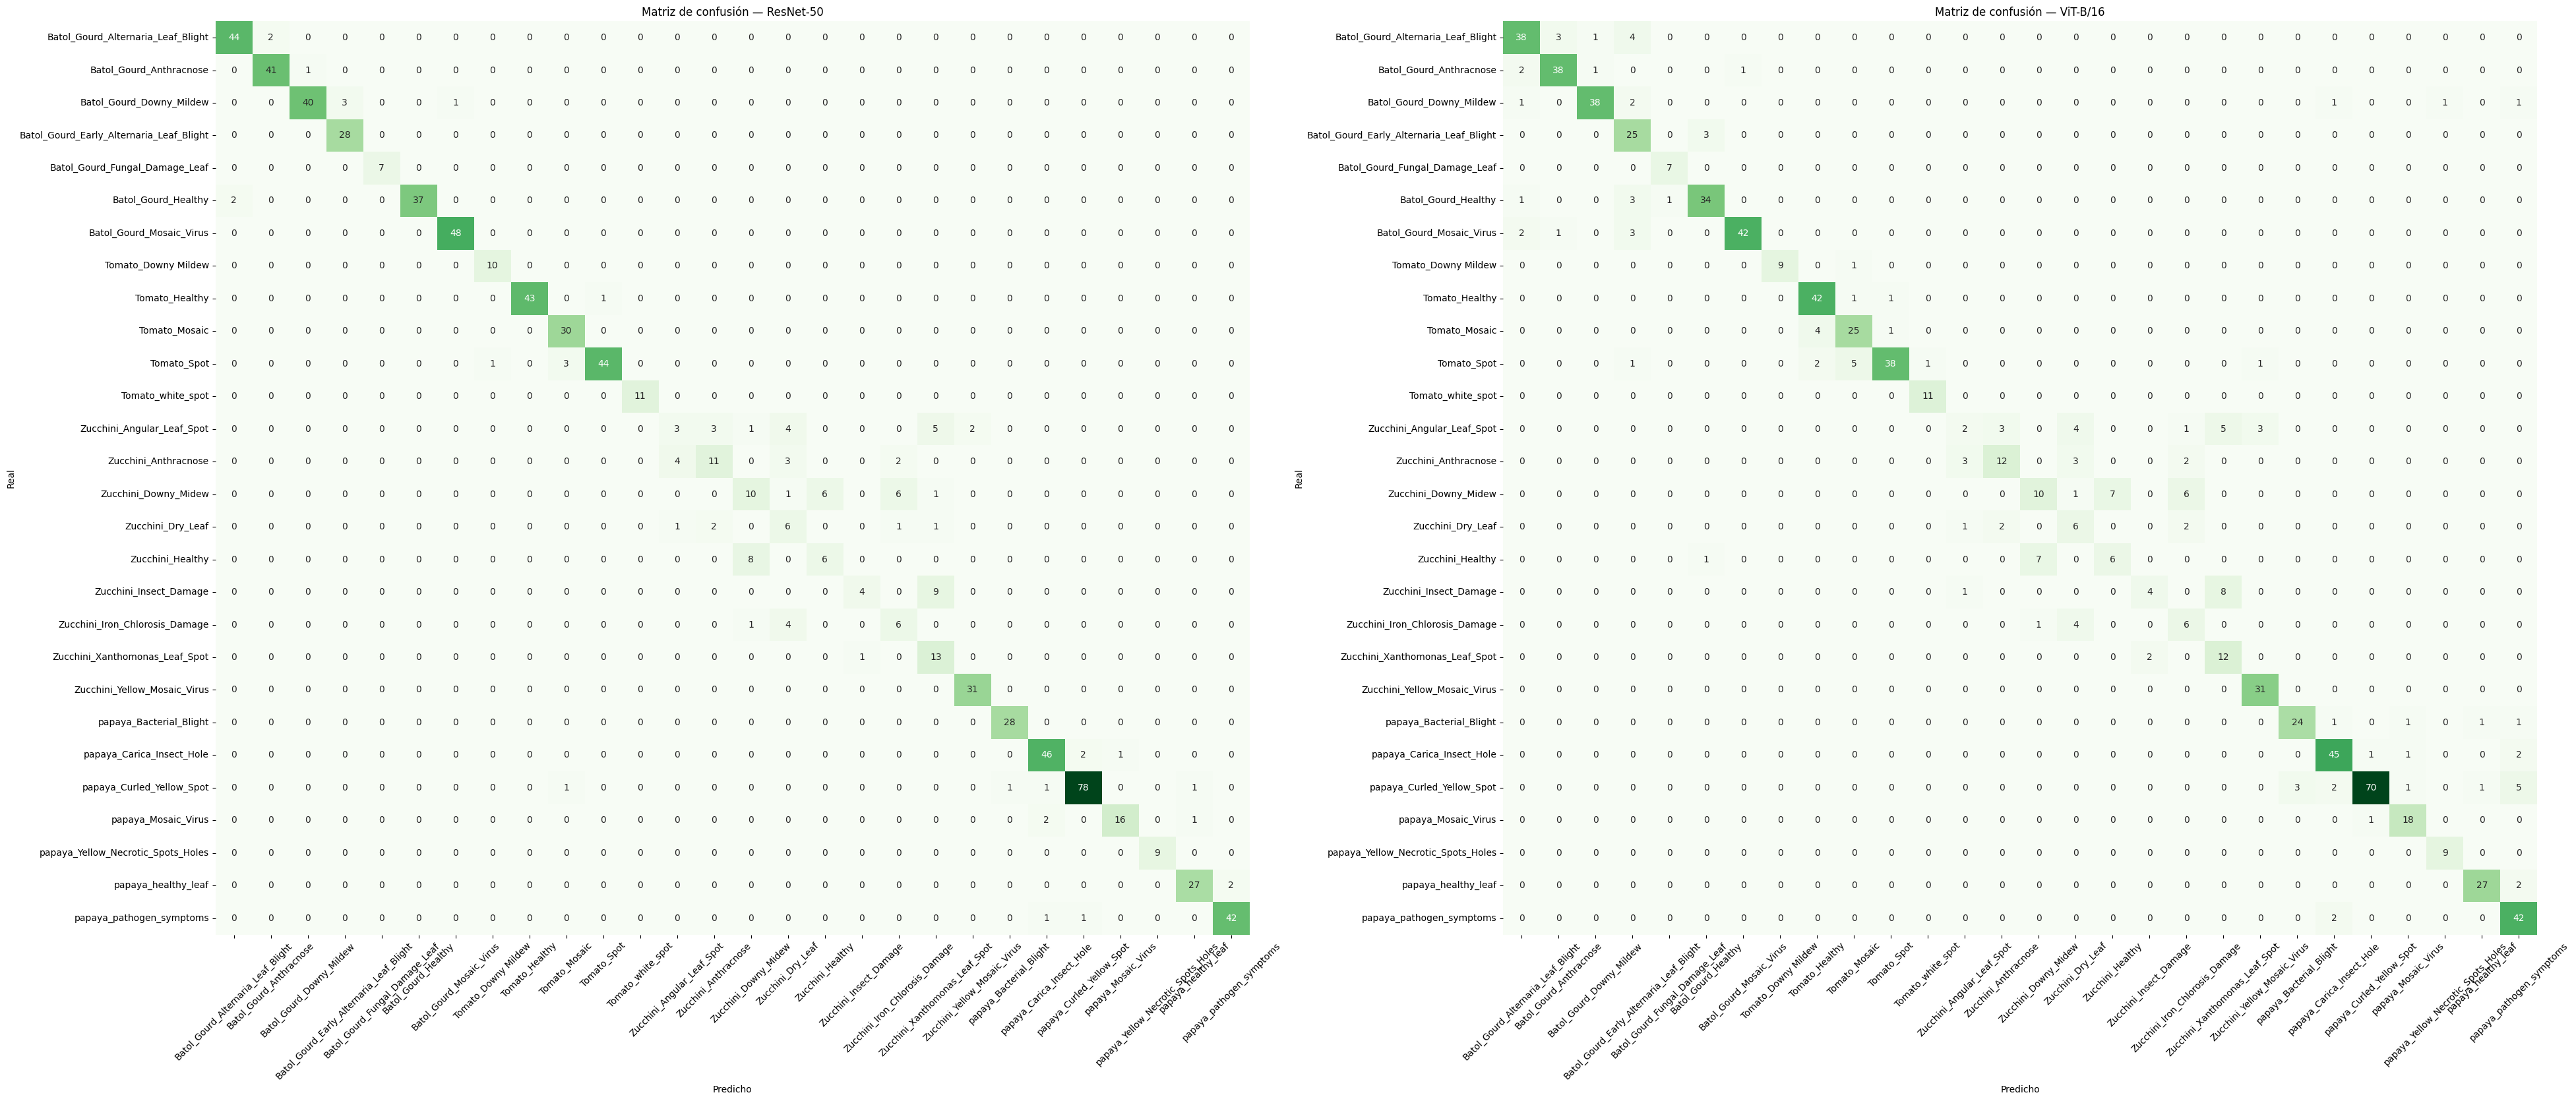

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(2 * max(6, NUM_CLASSES * 0.7), max(5, NUM_CLASSES * 0.6)))
for ax, (yt, yp, title) in zip(
        axes,
        [(yt_r, yp_r, "ResNet-50"), (yt_v, yp_v, "ViT-B/16")]):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"Matriz de confusión — {title}")
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.show()

### 8.5 F1 por clase (¿en qué clases gana cada modelo?)

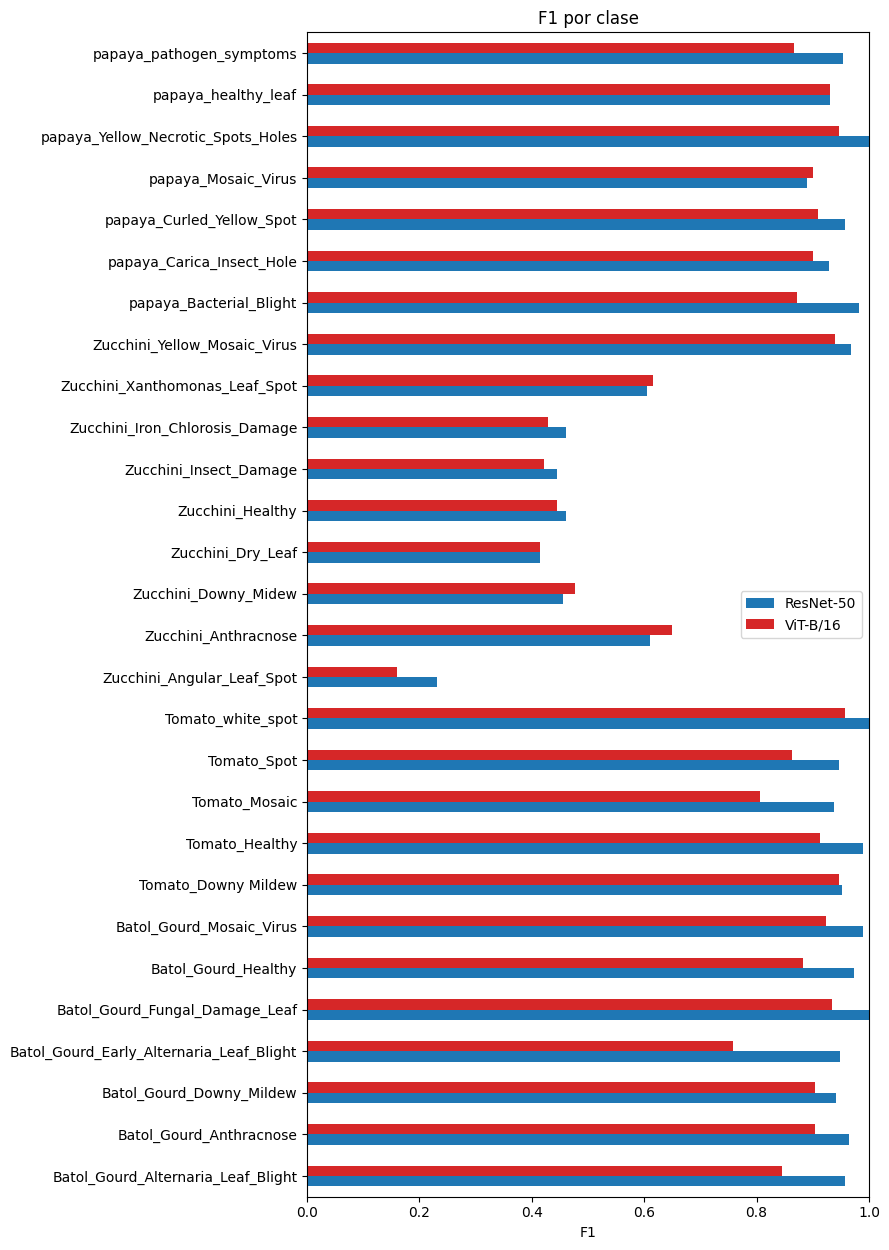

,ResNet-50,ViT-B/16
Batol_Gourd_Alternaria_Leaf_Blight,0.957,0.844
Batol_Gourd_Anthracnose,0.965,0.905
Batol_Gourd_Downy_Mildew,0.941,0.905
Batol_Gourd_Early_Alternaria_Leaf_Blight,0.949,0.758
Batol_Gourd_Fungal_Damage_Leaf,1.000,0.933
Batol_Gourd_Healthy,0.974,0.883
Batol_Gourd_Mosaic_Virus,0.990,0.923
Tomato_Downy Mildew,0.952,0.947
Tomato_Healthy,0.989,0.913
Tomato_Mosaic,0.938,0.806


In [17]:
f1_r = f1_score(yt_r, yp_r, average=None, zero_division=0)
f1_v = f1_score(yt_v, yp_v, average=None, zero_division=0)
per_class = pd.DataFrame({"ResNet-50": f1_r, "ViT-B/16": f1_v}, index=CLASS_NAMES)

ax = per_class.plot(kind="barh", figsize=(9, max(4, NUM_CLASSES * 0.45)),
                    color=["#1f77b4", "#d62728"])
ax.set_title("F1 por clase"); ax.set_xlabel("F1"); ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()
display(per_class.round(3))

## 9. Conclusiones

Rellena esta sección con tus observaciones a partir de los resultados anteriores. Algunas
preguntas guía para tu informe:

- **¿Qué modelo obtuvo mejor F1-macro / accuracy en test?** Recuerda que en datasets
  desbalanceados el **F1-macro** es más informativo que el accuracy.
- **Costo vs. beneficio:** compara la diferencia de desempeño frente al **tiempo de
  entrenamiento** y la **cantidad de parámetros** (columnas `train_time_min` y
  `trainable_params_M`). Los ViT suelen necesitar más datos/cómputo para brillar.
- **Errores por clase:** mira las matrices de confusión y el F1 por clase. ¿Ambos modelos
  se confunden entre las mismas especies de hojas (p. ej. hojas visualmente similares)?
- **Curvas de entrenamiento:** ¿alguno muestra señales de *overfitting* (train sube pero val
  se estanca/baja)? Si es así, considera más aumentos, `weight_decay` mayor o menos épocas.

### Ideas para extender el experimento
- Probar `FREEZE_BACKBONE = True` para comparar *feature extraction* vs. *fine-tuning* completo.
- Añadir *early stopping* o entrenar más épocas.
- Manejar desbalance con `CrossEntropyLoss(weight=...)` usando pesos inversos a la frecuencia.
- Probar variantes más ligeras (`resnet18`, `vit_b_32`) para un análisis de eficiencia.